<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #8b5cf6; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Fundamentos de Redes Neuronales y Propagación Hacia Adelante 🧠⚡
      </h1>
      <p style="margin: 6px 0 0 0; color: #8b5cf6; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Neural Networks & Forward Pass
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #8b5cf6; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/02_Fundamentos_de_Redes_Neuronales_y_Forward_Pass.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. De la Neurona Biológica al Modelo Matemático 🧠

La inspiración original de las redes neuronales artificiales viene de una simplificación extrema de cómo funciona una neurona biológica: recibe señales eléctricas de otras neuronas a través de sus dendritas, las combina, y si la señal combinada supera cierto umbral, "dispara" un impulso hacia adelante a través de su axón. Esa metáfora es útil para la intuición inicial, pero de aquí en adelante este cuaderno trabaja exclusivamente con su versión matemática, que es la que realmente se implementa en código: un **perceptrón** no es más que una suma ponderada de entradas más un sesgo, pasada por una función de activación.

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b, \qquad a = g(z)$$

Aquí $x_1, \dots, x_n$ son las variables de entrada (las columnas del dataset), $w_1, \dots, w_n$ son **pesos** que el modelo ajusta durante el entrenamiento (cuánto importa cada variable), $b$ es el **sesgo** (un desplazamiento constante, análogo al intercepto de una regresión lineal), $z$ es la suma ponderada -una combinación puramente lineal de las entradas- y $g$ es la **función de activación**, la pieza que introduce no linealidad y convierte $z$ en la salida final $a$. Este es, literalmente, el modelo más simple de red neuronal que existe: una sola neurona con un puñado de pesos. El resto de este cuaderno construye, paso a paso, sobre esta única ecuación.

---
## 2. Los Datos: Diagnóstico Celular 🔬

Para anclar el perceptrón a valores reales (no a números inventados), se usa `diagnostico_celular.csv`: 569 muestras de tejido celular descritas por 8 mediciones geométricas del núcleo celular (`radio_medio`, `textura_media`, `perimetro_medio`, `area_media`, `suavidad_media`, `compacidad_media`, `concavidad_media`, `puntos_concavos_medios`), junto con una variable objetivo binaria `diagnostico`. La estructura del dataset —mediciones morfológicas del núcleo celular usadas para distinguir dos categorías de diagnóstico— corresponde al tipo de problema clásico de apoyo al diagnóstico oncológico basado en datos (no se asume aquí que sea, literalmente, un dataset público específico; solo que representa fielmente ese tipo de problema real).

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_segmentacion_compleja.csv": "...",
    "diagnostico_celular.csv": "H4sIAChomWoC/219244tO27k+wD+k0JBoqjb1xgNuzHwg91Guz2Yzx8yIqi1tjEPveuc0zsrMyWKDAaDzL//5V//7W///O9/jT9//vHX//uP//77X/Bvf/n5z7/+/d/+/a//+Hv9v3/5+1/r//qv//7L//m3f/3Lv+pf/+Vv//6ff/mXP/7Df/zLH3/jP//7P/7xt//6Z/73+Af8xv/6if/rf//H3/7rH//2L3/7p//V9++9P739jvPTzX7jz9b6b/tpv70fjx+294ofI/5z/kff8eOf/pe137l/4uodfw77vfnnwnXt+M4L2z4LP8+6+NfWd17a72/8B+u/NuOi+D/ixm3wlu3mvfq8eUW/+D3d9sV1/dftx/Coe//O8zPO+uVDxa+KJz0jLzPvuKxN05NaPJ3/Do/bzbig2926XRv5Y9jB7fBn84G72a/H883f/XMs39Xjnp2Pg7+38aD453ba4SMevNT9jV/V8z1jNb1xVa6vwVfE2trGmjguG7+xqvGgZ/zceNyfGffiXzv4sXziV4yVy9PmPVPXtVzIYz8nFuRnxi0PHxG3usPyx5mXV8/3ZuvH/Lf5zxm/N19t1u3y99vALhh/SztTKxLbG+s/YoHjtSwWZsc68v2t4cHW4lYPu/w5jJfGMp60lpO2NmJd9ulals1FvYZ/u9P5i/IXwlZioeNZD6wsbtxt1IWwTp/5BHH/iRfoR/eLFYq/eSfuF4968oFhnLTj1nTDgTeYY72tGD9xEFb/ufmgscO/WMw+Ohbl5r9ZN228cSf8Nx7cdv55V/6KNQ/3osMow6TxgGvwLNTt/Hed3PkeO++/8UrrxK/Ck51FEzFegOvDpufVZsQlceHKE3vCMvetG24siGHvN380O1rO0/Pt+uforbLPM7gwsMw45zQav0frEq+Wp2ilrYUBzbWwMLER/KsnNlFGgD302OOfTis9OEn958zfOAXTms7fnjRX/P25sKaj47L7O8NA01hjUVqe3rBHmmkzGonTaOxOWJ+18FQduz/wrLZgqPNnN/+lT9jcvQF/0fbmC0wYW5ykvtJq8r5jxznsHhfq9NJHaFnjGnq2YdqNsL+4Pr1oz5e7ceHiQaeHmvQXxr2VJwyPErdasOt0nrfTSusg2uYPLGyH5dLWTt4sjnMcQO8/y51b33B64uLz8Yrt7DPknBa8TLqotIFYnPtej8sD/9KdNrpH12EKS5sRCLCa/rNxEvOvHyzGwmL0degu9ux6uYwQM2w23m7m280JDxqm5nzLyfU/MIO273wPijumIfDst3NkMYtveGDko2NhzF0BIiJWXL0zPsQ59fC93AQ63dnxb9Z55PsxPSj9Gpx2hsBzr84838zpD50+39rQWYoViZgX7xIWnBGwL6vlpJPZfL7F99zzjs/ZTW+Yb5ah6LS0NgQfPCccdhgpw+ieZWThH3LfL4wsTtO68hULtxsD7zcc77eanKHnjsd14UnSpYVvGuVDjykmwWC4nC1uX2c+XjXWM8LugUecsUr0e5ebPTYjks2loxi/sOOeEQHSaGLX03MseaeIQti6WH24mxbBBv/dzr26qcMjZlCLW//E02httHtz0hDwABGb3mVcnNi+WN8T/kkveTqfbTXeMf0LvIXMu2WUyLMbfqLHNo74kzGJnpDmEluD3ZgIcdj+xsiURpoxIvakTlPcE24GcCS2mJFmdT2p4QXjz/Ck4UCmz9p9+gpsY52Stvqs7chY2POO4UdjU+bo2v8tyMMrjjHih7exOlAzDS78oWU0jEdaBbhoofA3BbhawytGVAnDD7OLUzU7IUr/pa8XDnFsQjwg9jD+Qzxhr0fN26581NjhOcofTiKUoSVejG4uZJLOwtNGI+zGYXDXSdTe3UaXv6Zc/w5fxRvGP4RTG7n7Nyx1CV8cnJ64xaKdOdxTQpP0FXAa4WRjVQOTeB4Rt13vOBiXLm28jnGAjKl7LnjvePjYyPDzMyzn8GZn0uS4EQHBeOnW8YhlhKeKQLYRGH1srE/sHc7ye87YEzx/nGq+aVxkdHI9sXDiG4Hn7nT7uHffmza15MMR98PRRciIRd9wdFhRBs9Nm02b4ckeo5zq5P3ieIx8V29XZj4Zh6cTKI5Gw7VEyJ0esuelGQfCFyAOmOwOdwn0sQnAGTruLVSUxgZPl+5jBppaQqiDFxDuEYwl8hjlsAC/w1jKYdGxBlBb9FcA1K21RQOKI7dgshkc0///BpiZSBbMConJhOKX0egatyg88+WeIB2Ip45jsDyfd/Rez+u6PXezIadqCZVw03S1sY15QjxPi1kXhHctCf0c/gjjn1fuNV06cFzAzXAFkSEQOTQEb2vtfIBOmDIja6LpsJhw4oHf0q0m+lOwB05R9EaKQbfcuZUGnDrSFeTK3h+/V1ZHRGRwsl24eJ09aidxXWxsYpWftQpO0zwJM2UHYYx2+ZxOPBVhdOVfjge9whyuoEibs67jAbAIc43NT+fsPziNIyAO34xAPA5WowPYAAVhrYNwM+8dPnIEPj1pBTbb7/xGRT3vOPBnJIl7amHS2Fe6n0hpwjonEOcHUIfZ0AbG4smyTIt5ki9CVj6wZa7RicmxEE1Ilz+O8FGnXz6JHDzdjx7VK/IA64VZ8NZn0eztxCp1QB3LmJUnOm3o51otK9MwXq2zsa9XTkT8fjM79VwfrmkECkZIPp7O1myKkIY3W3m3HZYXNrNlbVe7to4pT9TJMj3nyuCaCXTmb3mzk1QDL2WWcJzO5+6lrGO8RCWdYq5teOUMBQUg7PavIBkmyp9zLm1HOo+F3CjDczIhFSXhbqz7YrD02hTQC50Wnh4AwTVyUl5mCJPDgePCYHDZahXr4v/Nm2YSHosTy6Z86tJeIhWmzzpc1wiZUybuE05jp0cOtx1ok5baldQOIh6ft8vEhyJWJkYz73xgsl+Z2KHd8PdoTQOZ53WJ42A38esC06YjP/sBcmRUCysUQQP2enxW9p4IOQ+W5T/3TOK5NJ1Bilty6dX9GU7Lp4xfGTAlwJnHuirVZKDYHbcL560gGbFae+hY1DTwTOcS6czCugI3jDxDnnHfSuAdSVVcf+Fdlx+GjjgF3I/rwv9Mb++onLrxUF2kVe2DruTP8hJ6EJmukUPLAwLocfJ8xAb4WvJVDN55a+EILFf4LJ/y/wsbGWcgAmQY8pov4Bhf7wp0KrrL58SFeNgEAp6Bea0iRgj+ns8YMqbIrndl1TtjTibZLc/HtlohIo2xPvGgbT8Vkw2xMS47YDhmYkmivklOo/HnEPSxWPoCdWlqBHURsZQ/KglPYM/r9OQFO2LDVzqPM/CggSXbJPhs4mJoAnzt02fRhEz+R1FN8Ry1jVv50eA2Kqie4tM6yS3PvDO8pE9lEI3bF/fHvYyJtV0Xw7EPvFy4qtiFjHLXFXKErAZj1XOU4ZPHlhNIMI97Aq14hujv1GyLa/B+uZ+jTCfgQtw0jObC6JfbHzgnIkNXpsY8+bwUK/kDT7By4CxnkWrX+VfP7Io7ureTF41TnGnSyOCRPvLCVc7HVsXD8mjgf73WNElmyzWN/faMdIRSisCNzJ0Nvm/fm4t6NnY/1hT8n10hjkhPmCvfSqsYlpsViEuEfdNbLdAqkU6Lr7j0wEd0r12ScXGui+FKqiKQ6qpMYDTGHGa3fS8RTvx9S0xOxzE+iTnCTcVS5C5yWVw5L5eHKeRIaN/LcaSb8/Qc8cvSc4jeVFQ79Bhhw1yda3jUOL/GyJrcDPj+KTyfBD74fmyFm5gWQesOSNyRO1iazQjgKRfKJCfSo6nMnrc8RMdpajsDa/zrytezq8VpoyhZetTBwBc7+UAnOM50HcC6ftqvfPFg/iCYtOQm+ZKi/gAfkqIecd8rnHtwT0REFDV4VvY9soEJiizicQDVWIF4pF/7grmDFyzfPFRtHQL5nXecea/wUnEqbTQ55CmGnGkd/XPuR+HVyGFI5kXUmHk+Dg/y5UbEI3uR6bS+xPa452WBYgEFxi3FI2Spwb5yiGvMIeKRjpbnYEPCBi7ecp0yO164nKwArf5+k/hhQIkC2hSprqSe0Rz+w7T/11W32TiG+dKFOo9VpYgxZm0FDSV0AdlWlXzyZkkGVfJZUGAwAVhKtcfsDFfLCgpE6EuGlVAgaxa7yj5EYl/EbHisxTDAzArwL85U/LnFJHRH+DfS8nE8WHfoVpwsnvMCPaRTbWJyVW5gQeQcZypZJj4yqCaHcEFbhfHQL4anoOHsIRZXzIfVdQeMThh8smSZCJR/3OIeOrNxepIGr96/vHhsbviqNJ6tyBHZpQxuKd/V0rZTcK6l17nMV5K0HkcbaYqmjTZ6jZ5uLtuPf+BrRt4Yt1lbkY448DCR6ENhZLgIBORh2MPRcMdbBAIvnPDMNl1eswBkz4JkuvL0j4Gs8lB+crnA1kr+DqGHnWPCDs7okdRs4pTAMSo6EOWYCQMsFf52UbqAclkkaWk3sV+6Y2M+r6SBR3Ku/s4UAuMdINfbT5rb/jrE7+dWLj/veFgXOTK2g/nKw7o6+FvFRiaeC4Qic1YgufjXA1r4k3sIis1dLJTI0t2KDdpdrqPosiFsRSi+2tV5lL2uyllGOqswgDjIgc/GvSKgVBJbSnPGbEqTdwGWC1OPgxohJ0xx7UN41cUeNZrCEG1n9ah5Vkbd8mccVUk6I5vOhy+ua3irpXCFKk6mV7EX8cvCOASQClHRaz2wshD+mT+2iWz1FSlZ/iFtlXh+f4jTtyw7E+V4xpXLUnmVCqJ+1oetRqbTFRtvrmf8rUgfE1XHfyEqXqpqycQDggnnnIpxGyRrvt/JQBkw/LfC4FAEFzUyRXTVXmSSkTnETH62J21pWtOpFFs0GymWDK+8DBxJnPu4LDyhVxrYmP+xfkQYsb1XRnaB/hOoAlyvo3LHoZ/Q/qfR0nCWFcJFchQI8iIvT2csIEeOTFyXqxQxh8k1xkJ2kAax5eF05tGBIhUSRjq2CBWypRHNi39uQContyNWbXYRKzq1e8q6ZXW2mMkdVAnyysCMKCi1IY7Eaday7sFntk7AkVYKyDmAc+O+oxWqIrNGDYUXd3Rm5Q2o/aZT3C1xwDji9C8Jitj9Lsh4GDn2WYVyp24Z6zIS5R5dOkhrHr9y/zSkkUkgrdVwhsMUwwLiNT1LuqImVfFnFTmSDnrkMbooK1bIc2t6Uog335fFfpbUyQUf1YWmyyEnv3/hzlvWkc7h+oSBKSujK4/35Q33rpPVkFrFDTd+S2QxCpAqHU3zP7n5K/ohIV+ezAX0eH9GQAgu/6wEnrXHOBrM59bUqex5Kkkm7QQCXlqORgmIkrLw4Sq8jeLYOx0BElaUoeZWUF6XJsiCQOee3LVKhpOMxSktQBJX3YvT5cIiH5gVwFaRFsmNZ04WsTV+ta9KWrt9InPkrsx5j+FwGa3bUFyfqD6v8wRDQ+8oUxez1wpbXaQscfSyGvCzlD8kB8j9GFP7QPcab1opXbiAjFgLbmRMFVnupE+cW6dRfGlfygMWWN2D0nNWoM5RgIx/UAX/1COoILWXwK6jLJjHNANDgF1VvppAdaMEgTXeUhvxHcF2RZCL37nO1NkSRNl1MBajzyh5hWUNMf+8eba0If2pPkDj0R1f+rtRNbqMPTdzrIOUZa6p7KqpgmzFABAYDh8lr8lj1SnngcBiqD5j0jlM5rvjo5aAjTfw1rEhO5fgZ2zpHRo5p7ldmYoylnnqYC2kV30iN4+T5Vd0x2ag9PFnUI7zl+fZEyRNcB5WtaArmOmUV7xLIkVsSMfjYVZu2mimBVkskxoP1FA6vvuStaSgChmFzAWKuC9RzUSRrSu+hhGtqld1naVMibJetXjHZVX+47M2CYha1hJN+05OJZ42XLglg6wa+9mM32OTGIs35o07oaOBUUniMYu0htLgLCKYr3hRUA4MxrLAPhLIhNuKR8xY4rl1PQtd7eOf7GDHjZGVwgmiXAj3OkB1OI613kFU0nLFIRQCOfcrAfTEORvMvrfSWKi2eph8Rr5zJCgQQpqos1v+ggBV+Qt6013Jx1EhCE9V/OOQIoCCpdjPjDVhCAk/lUqzJrxqN/QCzbxVVWew6JkO4FACWLVo1clPEcHKsOfp3+h6p0vfcCFu7YmsaBeKA+M0Ke3k6iALSCR5k0rKCGuVuDShHEk0xlTRflZsBjKn94gFVnjN3IZhUgXhQwjUM2CLZIFspoNKDqcS0F93xHoaC2Zd3mctyVGYfWBjDyrSs20a/dmuWk4rpYZ9V8xuJhwsgAd8SJ3eYSbQtB02+IxfNGIGq4WCB5BPqjiZiA0eZVLBjb7VsUZkSEAGJ5/UMvEMZ/Jdf5RWVFTi0fno5EZW8nnJqIyAgTrP+7pC1VJRR/XLscsbMyczFNlSJHe0f/ZdKFduP21J2NFQtTgFjpI5FmQVCI+1I4HFtArMg2ozPB4X8qUszntl81NJLjVvvdP0UJQgviZFgo2P65cXD3yIPVXvkM7q1uIY4s1M9Wcmyl4ajTvPVzadCVb9bFsYcALMZaADlXBnL7abWrcS7zKeb/DRBB1wWGA7cz37EqQvh8WC/NAba/tRVUulTETjng88pXSVUqGTmosjdFTOLGzklL2ktcUB9Yet7xI6lWxUKcux8lVJcaw88uGrYod2l4c8Z8tTHiFJWmrbqpSD7t554pell7M7S53HfMrEOG4KPfqdVQtulAMuRK0NzeL4Lj/tQWJWp2u+OkBH1JqosOYBflXkxqJ+KQGbCOFW5Epyzzgk8ZaR9W2oQuAJCaeWIPlhUB+dWUsWAmCsKZccDqx6X6n8fkRvTO1jsVb/QxF4obOJkJpesWld5TkIqvgzEl9GyKOUHvuZ6b99BA88TxQTDvK6jM6Ef5aMVdaUQQper4ReZ6JqyKVj2jpTmQbC7q5lXF69PR6IBUtdT3S9/GOq0GhdSMcvBcvSDlBL3yU/a2LkhKqJ3g5kb5ChZVJe5WNKNCozGyoIugmMJS2K0hHUnSPLAjRrZZBXIUdBC+oCJisUri7Ug3MXn+CBVZx6SyltIoPplauMn8HjhR1MHq6SB7q38ckg8pF3layQ7XYUZk6qAitlXS782BVQJXiZq2rl+ZiZjOf+XyjKxofoSiZSZCkrXbOXFAjFwJkS8DzVI29P6pH+eDadR4KAgFpTp4MZYGbKLSnZ/e5o81N4jnfc/8MCDJ0Y8WsPxEfTFXSOMl2/ooAm98dckgc1ReSyhtXNVBJrK8Nc6EmXKpGbP321QuQkWWIVE8zFe9otIlBkEjOj2AyVoKyXPBvl/bhdSoLmR/J+GLLUBRKHQ17yUw4yKS0O5Jp+X3RtVfO8UoWqVDJWYWWo+gdynTgYsw2xJYcFOukg6enWWaVhpqAs8WCu08+5f4SP8E9GuFytHSyVWfYCJMUCdeG4FGclxyksJYplsVQSZ8uKYItVG/ADkSKFj88el5LXcA+F6ePliTxjeb2cZM/7Ii1IwXsKenW8Kt3cEhjTPijxy5AMpfaF2sryl1R25dLyKzIH+KPxLqrmkjAY6uU5YOvDPiqJ5Ctf2mAXjR3AfhUfAHFI5r0oevS1yxmQupST7OycMB7peMsn1Mg6PciL4hEkKDhSQEdAk/LXCrkYdiZQVNp7mJ6JbTvi9aUQEFhyV8UMHQ/jglGGHVyrXOIIoBGA+FMVlNiXQg34nzDKucW1XjfVr4ZUabL1UVl9etsJHRuE+75Vb42EVwV9JXU6cL23opKg2u7gvePvjHO1JeTkO0tK4d6lvBagB94xANEDgDYrxh6VLRbrNJn+7Ie36diz4pmbIZ3P1DFRN8lUl46rCiYuCXuZUQFOZKflbxEC4skZpF1SutEKLDMCjfR4cZSmCw5u6ooCyFuVlJfWpirnBwx2bM8BwfzhzbfE8/zBUzZeXTj1iJPETOKm4SLZbon7pfILMyWSWE+tlXjLcyNSrRWJmYotXUKGrUTLq757ySkbNGymOATwOqRIKeEdpTq2aYKjMA9oc4deN36lV3p1h6uCJFnYKi+5bpXbgNCPPUbwo4BjK5nfTycEW7BwOlDEkJNscTiOnGs7X7p2U82s+tAu5D03nXJSl5mBLGGsJh0anbOW9Mxbh+oC8zbA87CC1aoj5a7XMQg1pHTwXt1kcebtsGkRiktrtY8UP1DO1vdRqPXqgDGB7I7AsTvL0JKRGat75i7trumyxSwS/RqpZCnRC/zbYGI1uixvV6k0sQ63nb1r7kJ0fDgWzLqUumewcYL8SoadVR2ZVl0zX4FudjH2Y9Te4dDnVeBy4v+RCG2pb8JUKpXVnFHNSwbJffayZE4YULfaAa/osj2+FTd7tnrDBY3uQLdpFj2nGHaue5ZHiaqsyrT+GqZwz/QDkEBdO08aqISQIfwKbkXAqrgRTzM6a8kZj7u/6AjhYW4393RJEuDlpSC2uck854Eaha8i9zzfiEytLba86knzKjsP79/Xpythq2WtOjVcbX5WGNsk0TCQJBk4yk9dtXUttpcwYH3cTVMrafxndAeNZzwMpiYpk5fzf4E8vc7Ks3+Tc1pDqoB4GaVIZMmSECLu+EAWFNszUiHHHzK7ZD8JzxY93LClUsvEpVZFjxQKObyI3/5nCxVbm0wgoDGvD0fF6LhQo80zLX3PlabIF9+zInn3RyWk3gbCt6QS4m2vMoJTRDtjVhjhlWD8015GhXhC899MmCQrNFNBSdJ5UyHzI0kfiDkLePBCOqWCUhW9uP3xmDShbL+oKv/p1VFsqC/1YkApzMlsWdU3JhbzeCkv55UuMUBkBMRUegyxUQw5rQonPKEBsr7lJSihHlRs56kgwrw3W1z4K9QoOnavHC+VEAvOFQKaEol0kQNk3K5JCrce9YmezfhL2/Nhsw9H8bEk9wyw5jIiJWqJPRLuHPBYULYX+JCsmBniooO4vqpCaK76cgdzflrpSyn453r2W2BSzVSEEGgM94x5s6iaeNAjquYrUx8iaA2McFYiN6Spfm6hVuI4N65sY/NnSyDgn24h6uAiVU8I8Rjl1VR6k7MTbEld9QfugKM9MN/ZVVaKTEeAU8fbBJSUqndJ6CKgRtRKaPYaKbgsotuv8ZbzU8gc4MDiZmFuARTS2tWKxY2chAXZ+nfVw1FNgw5bj3/NawZUzdXFRcCjUKnItFpV/C8eFhllXndkOxEN7KvRsanu56fXplxo/htkFD1lFKMqUgLbQr6qMownv6X+KkLERoNjsidbSSyPIXnX8JsiFqyy2CSxUbJP8U3gs2u//VOZ/RhEV/ntaQUHgUvCkIMq1UeAS/4zfLKpz2iphq+GvEaZUAb7CAvxouPR/LOrMU6XmiDzWPfTIJcHDBxaizftpaZYInhJENtHilcKDuOVO3FaYufCFiyXJjLjGjljC2D3R4c5kkNd0Pw8Haaqy2vfklTzylKogCnqQMt2kZB0qf6kFnBqFKUEWfYZiZDI9/4ctLj47rIgJ93TRIIrgW+3MHojb7ceMemlMjzsqDkEiKM6ZZ7UGGndQnEiX485AZc0LEFGI8e863Cxv6HjVIZ7Tz1kV/Qa6nOkC1AppE+dkURLBro+/Wu8Yd+lh9AJXmVuYu1S7v6yrYmGXE/kNUedrll6COmEIsnnP0DKz64q1GAD+aDXwVVG30WAd/m8sY6u9P3AE1QYHBpwMW9ArLS0t4tbknCCNdJwi0+NA9qP3WqbeuxKPlQ9py4nMkUisFhAe/YOX9KhrM+FKmXl4Q2rRbJPKc+7l652QZMTT3vRMBfBTbLj1c/naCQckVLhqPzDtgqoQY+xmFvudl///8Vsm142AdFhupWN6RXZoCmq8SqNLnZblNG5bVf/oQoW02HJonJFFCWW2P+joOaEibN6uk5VYmYRqUMEldpCE0GOj6i/I2imqH+iAqR2PvXIWZdalf46e0P6H22vCYvZ/dpsv0kgosb3Y4Kb+nqyEdDoD3LQxUar3PzyXtLwxA9Rpa3cNJV5DfQL6oaiGKe0+FOnRPra9XpBjW1kuf2Z+w8r18Uu/a5YrYRlZGmIrqRTtJ6GgN6lCK3Fv5CimFIuCqhuW1+tZCOT1DCeYzCe891+qj0ZknHoflT05wKPCYdZ9AIXkmMZbLJ0NV/fGrxBBIsNJsTn65eWInuK8RPrjHZC8bcgqgf0ChMI6H7pVLYGhwypFazKf85JEMnfX/TCri4u7EpHNVk3aGq0CNMYZXIN23ghr8+SnAuN7HLlqjXFcWZFINXn1YUIQR6K8i0FLqfQAQv3GpgQqYvK+sxO8jr2dXG+w4xdWSU9JZfJaCDRw0aFnF2PQ8x46kizLWxU0keGWQS5WtA2iBXCGPBo4dMOujtnr9aluTVvSKpyEmt2v+hmEnAbKHMIOUkjn0Xfq4PIFU4lY4k6DTpSVCszRR2PLtRuuMsxxxEdkkmo94mqA7TObRRmUrQkUlpw32j0Of+Cdz5TLUzgOFKMAhIgjKIf9SFwP9jS3ilcUz8lVwncn42H3L3IWGmt75pPXQdmTPzfKc3CQI9fyp5u6VAYwjpbGboGIakU0BCIWA0Cuh3QpH1UGZtNN+HN6RX6Jo4xqEjTcyQ9DvX8fsCCxkcjQlMHiOeqzaOQnHOIHHKpV9HZqltJJq0H8Nf/nGQiZZMLfUl2msoyXlDfzrfmzewWtMhLAcJTJpEjNGpSj1pBNC9nDv4McFLJ4gKZn2o5tOjEDr5WZkK0ailVTbKNL6XMBMs589iUUqbaJozP7DLbYUWP2JIEDXhiWC8e/9hXpSQi9akxIftLFpqBJBxJ+OgwbqGgoWkYCtRNxBz9Af3X5k2xKVncXQ9SaPQNPYgXUTLt4T3QQA3kcViYt0L8TQj6SCA+RT4Nq025szZlA/DZkvPSCI72yfgIMV9nIdlVtBenkKhIq0l0J3HeO+boGnoVzOygQy9CzqQSr6dOJMPUq0A3nFYimtQmaGfkUj2xaY4ZaVVlu7wO3VpDEfv1TqT4ZWJZk2IozUR1T6o1PKCERDOzbKeTathpruboDFD5QCqrprKXKpCYeqckHjG6oQQZ5u9nluZOHabSoZCxuP0Lj6KMnPKTCzavfbFyElrcJZFOVVnHFw2IruZ5K22TVHJqCFZXWdkk80+kBBFbdnlzctAjDaTO/oxEkbZ8HIF2Z3thzqZBNcC29rEp3NbELZmOtyqzTgooczZceqKk80SGle5durmuwzL9TXBhH9xGhdZRxRaKlVZCHV+V2ZgrLTYlqIn2oWn0x6+RL0gw+Ecu3ks7u1grSeTf8po4y5WLn/Ut1ZvqifIzaviLS6+bs3gilkyrWvQo+nBpgoYWiSyHNU0qyu0ZGK0Q+/HKtJ9Rc+kBNZvjvBZliNkGLoR8opwleyA6ZSyR5KrgMguysT/FErONjmZaGhzn8AQuEPwd6tpJDlQMLWSFCPWgH2cBqCf6nxr9UYMZ1EkHQauxY4TD1I59zwzonPVXRZPZCgSxIIE9yfzxeDV9bhJ5zsBwevXKlztQ0xdYoGxR6TWOR0NUliYrVOXU1qy3HCiAp9QU1dNxqu4leQ83RgMVMYIK+7HQL5ImMTijcLwOLOYk9NJ9mnrs/ZWFkUalHwFBO3flbNIxL1Ugbc5PA5CajbYu7agk7teexGqEtA9raZJLxlxxKluyvZ2P9DNG1U44Fq9T728idV6/YIqbD1zQBIW4xFdtSYtcmUwvd9DfFKin2j7o+pinvSlHUrMpqa3WeH/0Y6MAH4Fv/IzVFUmAtqxrmAZZ/jVWKcylMAM/En91SLhP+cBLvrYGnRUKbl4l2pZJSunSE5pXA7ZQgdeowfI9DYN4No7WzlkVKoKFsc3PyMFHJNp9apZxJaM6MCRfJtDkUhTsby2cnaLm2dYWdzyT04pk5keB+VQjtuYbvoEzGeV4stQXtVzBpORoknpxkGoOPOpfDgQMwT6cVFE1iNdfJDmDLrVq4RzIgtAeGTaQ83HKOW8K1F5x3zQtIRVShUSAfn85eSoTjLrrqHGf/oWlbavHiWVeqnehgu59V+GcaRRHup25XjvYw4ZQ4y9AmQ84vPTlYa7VvS169bV/D69JaVA52iP0NPCTWtoPkTI1beC+qYrulVvCY6jgzqLr7cQ8+UDsGEgiBRofb8VvLg7+5GjE099vIfOCYb2w0raRBdtnwFAmB4ICSoqHlUKssYv6QN8zIfJWGUBqglFTO9RlYrMcx+wqBECmPafaNincr6qpekvmeO0sR2DwADZlV8PQDUVmXHVGq3T68lFmIQeneGR3ieaT7O3qZqXXkWAiS5m+Pg2KHIwGeVhy3Kon0gEsqWhNNGtfo5RBF1EuWVZDFVwJDBksI9E9NMi3Swvd2fCb12a3V/aY2csI1Hxd5YNiNm5hrLuEWVL8EsjDZhGj9Pj7qHCpsSP9vC68CysN95zVjgPlvbIfSSyOtJ5q5LRXvOJE1YvGz7i1rzIDuQ6fWw2KKtm3WVQ+R93Fpm+UpceuVhOxGHSprhZLu6PYF8L0gxaKZI3aG6VMCzhTmtbS/JRnPRzoCC41pfRdnN+epZkg7by6IldVwTEN29htlJXT2M2uepBma1KDqWkOkTM+UgzU1sUB8/41ymd9S/bBcOq4zDLbsdTevMGuvs7o844GGRHT4bT+FbWW7D3unFm3yNstYZE6fxW0XK2jiQiYdE+c6Ti6DyhdzS0cf7Dks9v5muuJYTWXtMb91JHmR6wagWBWabtUnzmwGAOIc0JyGH6vdl4eLWctM0v3Si7G/dTdc5rTzsMysn1YY0ivpsAd9YlMdfP3rckj2UObGDZfNGLfLnZb3bzK9U0jwdC9xmfl9LkD35w1IWl4KbSiqXcVr0iPMA/J8JGnq4HSklb0jWQohkAVNvNXmuHwAIfoM2x7nFYSMYEx8gMBIPmGvUYdI2HSuLtMnR1Kfk7tXt8y3MmxkA1NHQIDgMsXLQeIeZqmzlbzTldQiuoy1tVVL93Q/ob3/UNHqyRgi/Bxv99Q8KYNHDTlfoSQasZSOCg9neee9if1uFnCXhyWcm5pBGU+EtEewft+VyFeiVNP9nFFdjBaVa40dygSdFP71pahzzcNCLWKe6rjcIyn+Fxf8r2lSWJWoxIbRe55IYbzjXlLYCJ3pdS9Clj9IxTJihvU1GEHzt5sDS+cfxRXUJxlwfSrqLwTux5Ok2y91BP05C5rFU8ZhvXmQeFATw6g6D/VIFPzzozqFjDqHDVb1o7cZ6GM7dnRvf8YQi0XW7HX9quYdnDVGR6U/lbvIQfHdOdMD/1bDTw/ICIwlkFDbHuxRDwlkbRp0no1k/mnlytTdbJvOd2pXNY18ei7aqY1LrGslrx6bMiFcmzeWzMhvx5YUWT5qoFgnOs1OSwzZ0Le13oqqUgNrVIZu9VcT7RHY8QWRsKtXr0V4tLnqfkaksNc9y/JTrq5QFtw7TUQjPMKm7TmVbDCJHvdk1qqlfecWSh7SmN9b+BxoSVwm9UJchH2DMKmgdHJPJPFZHTx6yqaLZWUIaU0DDHusKTU8SmJoffRyG5VOtioTQlEzaJUOlF90ufwSC+12HfBguT/vxJg0loLQrfhmkd5NCTHS6R+pcDovaqPbajs2dELel+to6YCVquzundL1ZThEla3N1TcXj0dGs0kB+9CqKa8ciMu87Yomd3zyUXIizP3EYdHTo/WjmOJXvnDQTvVpKZ1EjhcT/dDK5goyAyv+YezIonmwKnIpWW2a6Xh6xrU1kGe9WRTJY2WipZT/tUq0UmedDB1nJizAWJqKEh2io7PrPckeMRsaw4FjNTQRWIbjkCiwc5+80SznRNFSgo63lzJZDJQC9wboFsVjqGeGjXXKcreN25xjoqV0HrkxH37mut0hdaXTufyOz89K5k/TWT5BrWP1MynJphzPdf6YwQqM16U9Q9mTM9Z/etSwEVglLuSEtRWxZEFqGXQeiQh2mvy/tC4KwnFdhed8RibbMqYaOdI/UFKPa5UCJJ6tJqWUbOQz2cACjBeTV6uIQ0KVVNEyKs77FUBnqJsxPcsB92aSXyPeo6E0qfGbmQ3guqAJxXPKX2Fn7yjBsyeKw3eFz+wnAp5Y5Meqrs9x4XnqN+yoKP23rx8cDQQWSYW19CxAnkHRoSuaj+ur3OY5p5sveP3tMYD5SgIEe+V7qlIOU/py5YEP/vPSeoG9Y2dj/pme30NpkRtQrPn7aXr0yLZQxSu0sv0NIyqel5K1101h+4auFKz29er8M+vkSTtyb1UQFyg7HruYxZo38yMGpsiDqS+LZJTpm7NeEm+Jh8AmuxbpcdLubIxVTRGT7aZclVN0s9MDA7Q6PlyOWxE1bimOauLHM1LB53LKFcmouxy5kv+W60YpCcDfT26Lwuj0MIhGuSA+vs9Z15p89p/dHdjgAEZxuxZy563WtMmBz5dnKRmN5gVH5KhEkTRhuF6jenYq76yc//klpB9ZEQnjuwBQf+YBaAKck76oZ+br7x1IEDYOMWHQ4nFg7h4W00sGBoNtyubwKeZ8pMkmLiwuioMAcoVz4+GQ0tAN8tvXEHeFBpvICwp7ayyXwUqE/R9Ew8c5fzJPqfUwpXUXa2dRWWzRJ55wS1dB6DS5LyORLA1Ho49s4cf+VGedvutLL9zZPMoFmS+JEY88ZFw4Ha5LNuf17x5InNOHztW5OTkWEsIIFdir9XJMT63rfe1iGofYpDrNbFNVejsspFYFEDA35i/J9usr63oszuuz+5Unp51Kg5Pa0nGbX8fJyEgv6KyutoQXsMadE8c65BHY2sm6Z2EKpQ4hBeXu/L1NcsYpymRRxbmSzC8NPRIIGf2+urDLfmAg1vKhiUD+OjrqS8pzXHKL8n01kZScAAibIOITfXA/JpfXyMzXZ1Eoz9Sat2fmraXk95qpNB2NbloZsVYqmiMVkP3OLLf0dDXOe1Zze9XlB89v7JCSSg72hXTm7PPJoBdCYbL2pamL3r1+5Zc9KjFH93oB+Mh2v6jsGXiJfns+w85LLyBhoI8+ZvUza6OwKwclgiy6rgdw3Ay+YHZ5pQwaV00wdCk9j0iXdZnKqmh/zR8ZKb7p6K5tA1HDWzrqLvvzrK9NSU01tcJTk18lmC8PsPAF52f8o1vzd9L3S8nzCoUlChNubpozVJFI3xkKsDxopk9r+pzqHY8zcARg89p0bky/PodPzKFD5tVHnskUWawE6Ni9RUm0n1UO6QLeW2dR73zy78/5bD6a0M6JunvRQv0vPW9N417ZbFA2HDtWVM0J79vYiXY26s0NucLAEwt1TDSbtRtawB3jfoqtdRQcYsBWnr+1vR5CoMQiPMPEJmdttMXNtBMY81pc/i+DSM61bNxcnL2VQoWNNCWXwuyap1XJtNGMcWGsNXQlJEkxqxm/bs+Yw3jhG4Ri2t91RowXHZjaYYOs3QNcs6ZZcmPrBosxgALSjtFJDUF062yV4EVFcdqHAHYts8X7cItD2WS+mgDyz5NFUD7o6lmQbSUhf/3jcZKXNb6Q41qaxQTcVDyw5TwtXAYa8I0n5DfYwqsqxxifgrGSggPhgvPWbqjmoIvzyzn96bKTNQ1Fwfw3/cFvWwjM5EKynVNI7/kcmZ16e/6uk19p+iqH7iU0FvjNB2uqMZaU4m/jb36jyNWo5yKKarLW9JLb84TB5NkY1ZGy/dxm6U2UAobluY5zpplcW7NXRmNLQr+R8MSEZMTNV9lLdS/vkwgfdWVseoLVdpKP6bCXKuyz0Zk5pcsO647H1FoLy70fIab41BBJJrAZaINyGbNwJEI1ZSxqDLmmjCOzzehchoJOPQ1/tJzfg+LH5n8/pzoazfKiJN2PWqyU8nKndOkUogqEftc67XFoNC4jsBVQh1RmKJqpT48NU9CksdUtydOBj8c+euX3Fakm7AnqTNzYqT8ohFGr/WUzc8B2fz4nj+0tCbUTmf+8NFS8FtK2U/HbyH0ry8hvsl0NQDrzXob+BaibUxQTbFAiT40wnyNp+w9akJ9yBMzPrIJB2XRecVdmBrbtiZn1piuYi4amo0cXzVIDFCfKetfX6jhGEJisq9BlhkYUUs9ia1K17CLQZb3VuXQH2uB+M/aguUIzPX95bc8QXKm9MXzlRZODd0S0p2VPaoQZuJzlKN1SikMHLtB8fGmCn0GZqyvTz7MypRnfTIO7p8JVnL8a5bi7Ow/vxm1qnZX95xoeYVin+G/FW6gZIh1bRMYGJ/RFZgPFldf9IHlSPvzJTmUIsYldeqveLbAQDoy1sHxA8z+mUzPqfptTU6gzijFAmDZEh1v8OC7KFqlrH72H3lnrMcFexT3iridFrsl3TqrxnTJLWsjxmOs+HVRRxkrDo1XfnSvSEQNitdU0fLCrnGbF18KC1PMKlb1POxXhi/hYpYIpMh18c/52VUIcpUz7urldY0gU6Jr3wwZuu8OPviV8FbvqIlS+rCQ1bhN2/Mj5sSo34PPb8xT1Cy/K1HVvlEdg4U1hwbfGCw8vxW0x6MCSVhs1z2lGnOvMT0DevDs+8PM3uxGUTwa/j0cSLA1FZn3WyuNsc0LH9Qd1qoyvTUicCmcyun4UIk5myvIJicZlPzeLPigfFdTvocaA+6ngZ1o1TC19dwn/Xp50tIE1BpgknMU61LWUVF6C58bqF2VDB/i1+3PfiaU3JSVSbpe0si56q7KV039x/PV3EDM+NA4olRTiF/bGl9QBUl18Xl9ESNLloaGi4nvd3w+NaNxS6qFDwmPup03F+Ck+V20+sxPC8Pp1Qyuj+P2NxKxLCHPM4oQC43zw3pN6pEcWBWmq7bcGjFcjUlZGnJOUShRRI1dahLzqvjfe9cs9Wz9Mk7euuiKeX2Vel7XiJe3IyB0DO1zF9X+NbegABvKVHSTcmns8SrhaBlNER96YLI1soZ29s/Y7y5X4jUSxmGfYJEv+lhWe18ZsftV36vqkI9Xr81xe+lUJRusgcbb9ckODQj8Un3leCcUAjoGJaVmXZzV+VJvqXDhVqM9LqbKNX44p2W42t8f8BRVFSkngwAHs3DUmlFp6Pg0le+aYifyiPNc2GMxTt0uDwW/ZT7yJZOLeB+Y+5qeqQ9j7VvSXShFGz9JnaO2CsS5IIap6lXS1FafaF9YyAGRcar2Vo3Zwv0Yx0fxSLgIod7w3W2H8KbXJ8Ur5rraxGv1/x9mzKlSdn8AAA==",
    "geometria_lunas.csv": "...",
    "rendimiento_industrial_no_lineal.csv": "...",
    "sensores_maquinaria.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("Data Mining", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        os.path.join("..", "06 - Maquinas de Soporte Vectorial y Redes Neuronales", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/06%20-%20Maquinas%20de%20Soporte%20Vectorial%20y%20Redes%20Neuronales/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=2) as resp, open(target, "wb") as out_f:
            out_f.write(resp.read())
        return target
    except Exception:
        pass
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv(load_dataset("diagnostico_celular.csv"))

print("Forma del dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nEstadisticas descriptivas:")
print(df.describe())
print("\nDistribucion de la variable objetivo 'diagnostico':")
print(df["diagnostico"].value_counts().sort_index())

Forma del dataset: (569, 9)

Valores nulos por columna:
radio_medio               0
textura_media             0
perimetro_medio           0
area_media                0
suavidad_media            0
compacidad_media          0
concavidad_media          0
puntos_concavos_medios    0
diagnostico               0
dtype: int64

Estadisticas descriptivas:
       radio_medio  textura_media  perimetro_medio   area_media  \
count   569.000000     569.000000       569.000000   569.000000   
mean     14.127292      19.289649        91.969033   654.889104   
std       3.524049       4.301036        24.298981   351.914129   
min       6.981000       9.710000        43.790000   143.500000   
25%      11.700000      16.170000        75.170000   420.300000   
50%      13.370000      18.840000        86.240000   551.100000   
75%      15.780000      21.800000       104.100000   782.700000   
max      28.110000      39.280000       188.500000  2501.000000   

       suavidad_media  compacidad_media  concav

**Lectura:** el dataset no tiene valores nulos (569 filas completas). La variable objetivo está moderadamente desbalanceada: **212** muestras (37.3%) con `diagnostico = 0` y **357** muestras (62.7%) con `diagnostico = 1` — un clasificador que prediga siempre la clase mayoritaria ya acertaría el 62.7% de las veces, la vara mínima que cualquier red debe superar. Las variables de entrada, además, viven en escalas muy distintas: `radio_medio` va de 6.98 a 28.11 (media 14.13), mientras que `area_media` va de 143.5 a 2501.0 (media 654.89) — casi dos órdenes de magnitud de diferencia. Esa disparidad es la razón por la que, más adelante en este cuaderno, `MLPClassifier` se entrena sobre variables estandarizadas, exactamente como ocurrió con SVM en los Cuadernos 00 y 01 de este módulo.

---
## 3. Construyendo un Perceptrón a Mano, en NumPy 🔧

Antes de usar cualquier librería, vale la pena calcular la ecuación de la Sección 1 con las propias manos, sobre un par de valores reales, para que el mecanismo quede completamente transparente. Se toman dos variables de una muestra real del dataset —`radio_medio` y `textura_media`— y se les asignan pesos **elegidos arbitrariamente** (todavía no se ha "entrenado" nada; el Cuaderno 03 de este módulo mostrará cómo se aprenden esos pesos de verdad mediante retropropagación). El objetivo aquí es únicamente mecánico: ver, número por número, cómo $z = w_1 x_1 + w_2 x_2 + b$ se convierte en una activación $a = g(z)$.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Pesos y sesgo elegidos arbitrariamente (ilustrativos, NO aprendidos todavia)
w1, w2, b = 0.15, -0.05, -2.0

print("Perceptron a mano: z = w1*x1 + w2*x2 + b,  a = sigmoide(z)\n")
for i in [0, 1, 20, 25]:
    fila = df.iloc[i]
    x1, x2 = fila["radio_medio"], fila["textura_media"]
    z = w1 * x1 + w2 * x2 + b
    a = sigmoid(z)
    print(f"Fila {i:>2}: radio_medio={x1:6.2f}  textura_media={x2:6.2f}  "
          f"-> z={z:7.4f}  a=sigmoide(z)={a:.4f}  (diagnostico real={fila['diagnostico']})")

Perceptron a mano: z = w1*x1 + w2*x2 + b,  a = sigmoide(z)

Fila  0: radio_medio= 17.99  textura_media= 10.38  -> z= 0.1795  a=sigmoide(z)=0.5448  (diagnostico real=0.0)
Fila  1: radio_medio= 20.57  textura_media= 17.77  -> z= 0.1970  a=sigmoide(z)=0.5491  (diagnostico real=0.0)
Fila 20: radio_medio= 13.08  textura_media= 15.71  -> z=-0.8235  a=sigmoide(z)=0.3050  (diagnostico real=1.0)
Fila 25: radio_medio= 17.14  textura_media= 16.40  -> z=-0.2490  a=sigmoide(z)=0.4381  (diagnostico real=0.0)


**Lectura:** con estos pesos fijos (no aprendidos), la fila 0 ($x_1=17.99$, $x_2=10.38$) produce $z=0.1795$ y una activación $a=0.5448$; la fila 20 ($x_1=13.08$, $x_2=15.71$) produce un $z$ negativo ($-0.8235$) y una activación mucho más baja ($a=0.3050$). Nótese que la salida $a$ no coincide de forma consistente con el `diagnostico` real de cada fila —era de esperarse: estos pesos se inventaron para ilustrar el cálculo, no se obtuvieron optimizando nada—. Lo importante de esta sección no es la precisión del resultado, sino haber visto, con aritmética explícita, que un perceptrón es exactamente esta operación: multiplicar, sumar, y aplastar el resultado con una función de activación. Nada más y nada menos.

---
## 4. Funciones de Activación: Sigmoide, ReLU y Softmax ⚡

La función de activación $g$ es la pieza que decide qué tan "no lineal" puede llegar a ser una red. Sin ella, apilar capas no serviría de nada: una cadena de transformaciones puramente lineales sigue siendo, matemáticamente, una única transformación lineal. Las tres activaciones más usadas en la práctica cumplen roles distintos:

| Activación | Fórmula | Rango | Uso típico |
|---|---|---|---|
| **Sigmoide** | $\sigma(z) = \dfrac{1}{1+e^{-z}}$ | $(0, 1)$ | Capa de **salida** en clasificación **binaria** — el resultado se interpreta directamente como una probabilidad |
| **ReLU** (*Rectified Linear Unit*) | $\text{ReLU}(z) = \max(0, z)$ | $[0, \infty)$ | Capas **ocultas** — es la opción por defecto en la mayoría de redes modernas |
| **Softmax** | $\text{softmax}(z)_k = \dfrac{e^{z_k}}{\sum_{j} e^{z_j}}$ | $(0,1)$, suma total $=1$ | Capa de **salida** en clasificación **multiclase** — convierte un vector de puntuaciones en una distribución de probabilidad |

**¿Por qué ReLU y no sigmoide en las capas ocultas?** La derivada de la sigmoide es, como mucho, $0.25$ (en $z=0$), y se acerca a $0$ muy rápido en cuanto $|z|$ crece. Al encadenar varias capas, la regla de la cadena (Cuaderno 03) **multiplica** esas derivadas pequeñas entre sí, y el gradiente que llega a las primeras capas se vuelve minúsculo — el llamado **problema del gradiente que se desvanece** (*vanishing gradient*), que hace el entrenamiento extremadamente lento o directamente estancado en redes profundas. ReLU, en cambio, tiene derivada exactamente $1$ para cualquier $z>0$, así que no atenúa el gradiente en esa región — por eso es la opción por defecto en capas ocultas modernas, a pesar de tener una discontinuidad en su derivada en $z=0$ y de "apagar" por completo las neuronas con $z<0$.

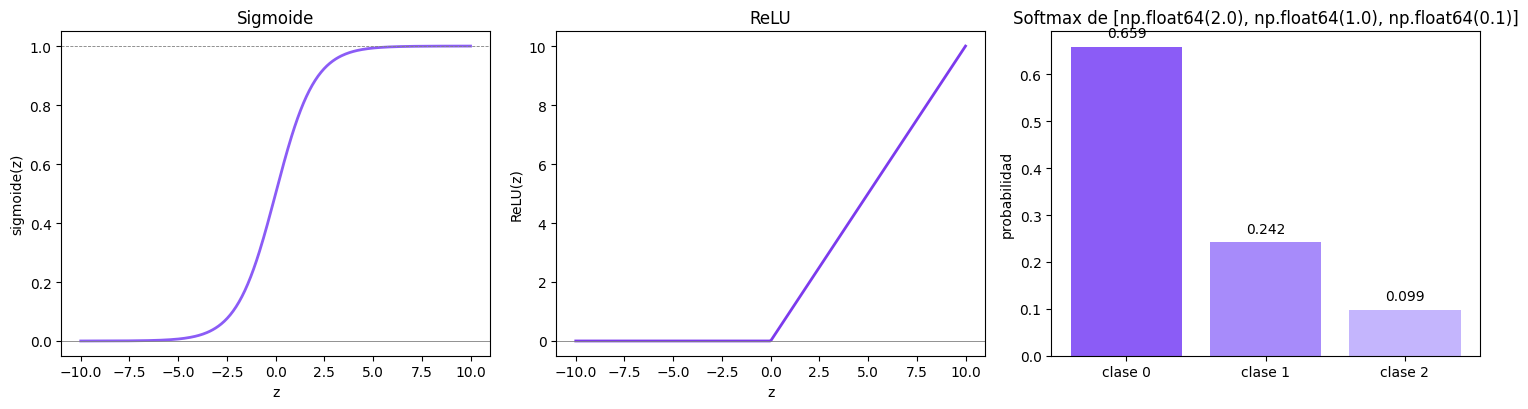

Suma de las probabilidades de softmax: 1.0


In [3]:
def relu(z):
    return np.maximum(0, z)

def softmax(z):
    ez = np.exp(z - np.max(z))  # se resta el maximo por estabilidad numerica
    return ez / ez.sum()

zs = np.linspace(-10, 10, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(zs, sigmoid(zs), color="#8b5cf6", linewidth=2)
axes[0].set_title("Sigmoide")
axes[0].set_xlabel("z")
axes[0].set_ylabel("sigmoide(z)")
axes[0].axhline(0, color="gray", linewidth=0.6)
axes[0].axhline(1, color="gray", linewidth=0.6, linestyle="--")

axes[1].plot(zs, relu(zs), color="#7c3aed", linewidth=2)
axes[1].set_title("ReLU")
axes[1].set_xlabel("z")
axes[1].set_ylabel("ReLU(z)")
axes[1].axhline(0, color="gray", linewidth=0.6)

logits_ejemplo = np.array([2.0, 1.0, 0.1])
probs_ejemplo = softmax(logits_ejemplo)
axes[2].bar(["clase 0", "clase 1", "clase 2"], probs_ejemplo, color=["#8b5cf6", "#a78bfa", "#c4b5fd"])
axes[2].set_title(f"Softmax de {list(logits_ejemplo)}")
axes[2].set_ylabel("probabilidad")
for i, p in enumerate(probs_ejemplo):
    axes[2].text(i, p + 0.02, f"{p:.3f}", ha="center")

plt.tight_layout()
plt.show()

print("Suma de las probabilidades de softmax:", probs_ejemplo.sum())

**Lectura:** la sigmoide (izquierda) tiene su clásica forma de "S", aplastando cualquier entrada al rango $(0,1)$ — perfecta para leerla como una probabilidad de la clase positiva. La ReLU (centro) es lineal para $z>0$ y exactamente cero para $z<0$: no hay aplastamiento en la parte positiva, así que el gradiente no se atenúa ahí, la ventaja mencionada arriba. El gráfico de barras (derecha) muestra softmax aplicada al vector de puntuaciones $[2.0, 1.0, 0.1]$: la clase con mayor puntuación (clase 0) recibe la mayor probabilidad (65.9%), pero las otras dos clases no quedan en cero — reciben 24.2% y 9.9% respectivamente — y las tres probabilidades **suman exactamente 1.0**, la propiedad que hace de softmax la elección natural para la capa de salida cuando hay más de dos clases posibles.

---
## 5. Los Límites de un Solo Perceptrón: Separabilidad Lineal 🚧

Un único perceptrón, sin importar qué pesos $w$ y sesgo $b$ se elijan, solo puede trazar una **frontera de decisión lineal**: la ecuación $z = w^Tx + b = 0$ es, geométricamente, un hiperplano (una línea recta en 2D). Esto significa que un solo perceptrón únicamente puede resolver problemas **linealmente separables** — aquellos donde existe al menos una línea recta (o hiperplano) que separa perfectamente las clases.

Este módulo ya mostró, en los Cuadernos 00 y 01, ejemplos donde esa condición **no se cumple**: `geometria_lunas.csv` en el Cuaderno 01 contiene dos clases entrelazadas en forma de medialuna que ninguna línea recta puede separar, sin importar cómo se ajusten sus parámetros — ahí fue necesario el truco del kernel para que SVM curvara su frontera. Un solo perceptrón tiene exactamente la misma limitación estructural que un SVM lineal: ambos son, en el fondo, modelos lineales. La solución que ofrecen las redes neuronales no es "curvar" la activación de una sola neurona, sino **apilar varias neuronas en capas**: cada neurona traza su propia línea recta, pero la combinación de muchas de ellas, pasadas por activaciones no lineales y combinadas de nuevo en una capa siguiente, sí puede aproximar fronteras curvas y arbitrariamente complejas. Esa es, precisamente, la motivación de la siguiente sección.

---
## 6. Arquitectura de un Perceptrón Multicapa (MLP) 🏗️

Un **Perceptrón Multicapa** (*Multi-Layer Perceptron*, MLP) organiza muchas neuronas como la de la Sección 1 en **capas** conectadas secuencialmente: una **capa de entrada** (simplemente las variables originales, sin cómputo), una o más **capas ocultas** (donde ocurre la mayor parte del cómputo no lineal), y una **capa de salida** (produce la predicción final). Cada neurona de una capa recibe como entrada la salida de **todas** las neuronas de la capa anterior — por eso se llaman capas "densas" o "totalmente conectadas".

```
   Entrada           Capa oculta (ReLU)         Salida (Sigmoide)

    x1 ─┬──────────────► h1 ──┐
        │  ╲          ╱       │
        │   ╲        ╱        ├──────────────► y_pred
    x2 ─┴────╲──────╱─► h2  ──┤   (probabilidad
              ╲    ╱          │    de clase 1)
               ╲  ╱           ├──►
                ╲╱─────────► h3 ┘
              (cada flecha lleva
               un peso distinto)
```

Formalmente, si $A^{[0]} = X$ es la entrada, cada capa $l$ calcula:

$$Z^{[l]} = A^{[l-1]} W^{[l]} + b^{[l]}, \qquad A^{[l]} = g^{[l]}\!\left(Z^{[l]}\right)$$

donde $W^{[l]}$ es la **matriz** de pesos de la capa $l$ (una columna por neurona de esa capa, una fila por entrada que recibe) y $b^{[l]}$ es su vector de sesgos. Encadenar esta operación capa por capa —de la entrada hacia la salida— es exactamente lo que se llama **propagación hacia adelante** (*forward pass*): los datos fluyen en una sola dirección, sin ciclos, transformándose capa a capa hasta llegar a la predicción final. La siguiente sección calcula este proceso a mano, número por número, para una red diminuta de 2 entradas, 3 neuronas ocultas y 1 salida.

---
## 7. Propagación Hacia Adelante, Calculada a Mano 🧮

Para hacer tangible la fórmula matricial anterior, se construye la red más pequeña que tiene sentido pedagógico: **2 entradas → 3 neuronas ocultas (ReLU) → 1 neurona de salida (sigmoide)**. Las entradas son dos variables reales de `sensores_maquinaria.csv` (`temperatura_c` y `vibracion_hz`), **estandarizadas** primero (misma razón de siempre: poner las variables en una escala comparable antes de multiplicarlas por pesos). Los pesos $W^{[1]}$, $b^{[1]}$, $W^{[2]}$, $b^{[2]}$ se generan aquí de forma aleatoria y fija (`np.random.seed(42)`) — de nuevo, son ilustrativos, no aprendidos; el Cuaderno 03 muestra cómo se ajustan de verdad.

In [4]:
dfs = pd.read_csv(load_dataset("sensores_maquinaria.csv"))

from sklearn.preprocessing import StandardScaler

feat_demo = ["temperatura_c", "vibracion_hz"]
scaler_demo = StandardScaler().fit(dfs[feat_demo])

# Dos ejemplos reales: uno sin falla inminente, uno con falla inminente
fila_ok = dfs[dfs["falla_inminente"] == 0].iloc[0]
fila_falla = dfs[dfs["falla_inminente"] == 1].iloc[0]

x_ok = scaler_demo.transform([fila_ok[feat_demo].values.astype(float)])[0]
x_falla = scaler_demo.transform([fila_falla[feat_demo].values.astype(float)])[0]

print("Ejemplo sin falla inminente:")
print(f"  crudo:      temperatura_c={fila_ok['temperatura_c']:.2f}  vibracion_hz={fila_ok['vibracion_hz']:.2f}")
print(f"  escalado:   {x_ok}")
print("\nEjemplo con falla inminente:")
print(f"  crudo:      temperatura_c={fila_falla['temperatura_c']:.2f}  vibracion_hz={fila_falla['vibracion_hz']:.2f}")
print(f"  escalado:   {x_falla}")

# Pesos y sesgos aleatorios, fijos e ilustrativos (2 -> 3 -> 1)
np.random.seed(42)
W1 = np.round(np.random.randn(2, 3) * 0.5, 2)   # (2 entradas, 3 neuronas ocultas)
b1 = np.round(np.random.randn(3) * 0.1, 2)
W2 = np.round(np.random.randn(3, 1) * 0.5, 2)   # (3 ocultas, 1 salida)
b2 = np.round(np.random.randn(1) * 0.1, 2)

print("\nW1 (2x3):\n", W1)
print("b1 (3,):", b1)
print("W2 (3x1):\n", W2)
print("b2 (1,):", b2)

Ejemplo sin falla inminente:
  crudo:      temperatura_c=77.96  vibracion_hz=46.88
  escalado:   [0.46417053 0.09977003]

Ejemplo con falla inminente:
  crudo:      temperatura_c=55.05  vibracion_hz=77.18
  escalado:   [-1.47311191  2.17345278]

W1 (2x3):
 [[ 0.25 -0.07  0.32]
 [ 0.76 -0.12 -0.12]]
b1 (3,): [ 0.16  0.08 -0.05]
W2 (3x1):
 [[ 0.27]
 [-0.23]
 [-0.23]]
b2 (1,): [0.02]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
def forward_pass_manual(x, etiqueta):
    print(f"--- Forward pass: {etiqueta} ---")
    print("Entrada x:", x)

    z1 = x @ W1 + b1
    a1 = relu(z1)
    print("Capa oculta -> z1 = x @ W1 + b1     :", z1)
    print("Capa oculta -> a1 = ReLU(z1)        :", a1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    print("Capa salida -> z2 = a1 @ W2 + b2    :", z2)
    print("Capa salida -> a2 = sigmoide(z2)    :", a2)
    print(f"Probabilidad de falla inminente predicha: {a2[0]:.4f}\n")
    return a2

a2_ok = forward_pass_manual(x_ok, "ejemplo SIN falla inminente")
a2_falla = forward_pass_manual(x_falla, "ejemplo CON falla inminente")

--- Forward pass: ejemplo SIN falla inminente ---
Entrada x: [0.46417053 0.09977003]
Capa oculta -> z1 = x @ W1 + b1     : [0.35186786 0.03553566 0.08656217]
Capa oculta -> a1 = ReLU(z1)        : [0.35186786 0.03553566 0.08656217]
Capa salida -> z2 = a1 @ W2 + b2    : [0.08692182]
Capa salida -> a2 = sigmoide(z2)    : [0.52171678]
Probabilidad de falla inminente predicha: 0.5217

--- Forward pass: ejemplo CON falla inminente ---
Entrada x: [-1.47311191  2.17345278]
Capa oculta -> z1 = x @ W1 + b1     : [ 1.44354613 -0.0776965  -0.78221014]
Capa oculta -> a1 = ReLU(z1)        : [1.44354613 0.         0.        ]
Capa salida -> z2 = a1 @ W2 + b2    : [0.40975746]
Capa salida -> a2 = sigmoide(z2)    : [0.60102972]
Probabilidad de falla inminente predicha: 0.6010



**Lectura:** para el ejemplo sin falla inminente (temperatura 77.96°C, vibración 46.88 Hz, valores cercanos al promedio del dataset), la capa oculta produce activaciones `[0.3519, 0.0355, 0.0866]` tras ReLU —ningún valor se "apagó" a cero porque las tres preactivaciones $z_1$ ya eran positivas— y la salida final es una probabilidad de **0.5217**. Para el ejemplo con falla inminente (temperatura 55.05°C, vibración 77.18 Hz, un patrón más alejado del promedio), la segunda y tercera neurona ocultas sí se apagan a exactamente 0 (sus $z_1$ eran negativos), y la salida final sube a **0.6010**. Ninguna de las dos probabilidades es una predicción "correcta" en un sentido entrenado —los pesos son aleatorios, no aprendidos—, pero el ejercicio cumple su propósito: se puede seguir, número por número, cómo una entrada de 2 valores se transforma en 3 activaciones ocultas y luego en 1 salida, exactamente según la fórmula matricial $Z^{[l]} = A^{[l-1]}W^{[l]} + b^{[l]}$, $A^{[l]} = g(Z^{[l]})$ de la sección anterior.

---
## 8. `MLPClassifier` de scikit-learn sobre Datos de Sensores ⚙️

Con la mecánica ya transparente, se entrena una red real con `sklearn.neural_network.MLPClassifier` para predecir `falla_inminente` a partir de las 5 variables numéricas de `sensores_maquinaria.csv`: `temperatura_c`, `vibracion_hz`, `presion_psi`, `velocidad_rpm` y `desgaste_porcentaje`. Como en toda la Sección 7 y como en SVM (Cuadernos 00 y 01), las variables se estandarizan antes de entrenar: `MLPClassifier` ajusta sus pesos mediante descenso de gradiente, y ese proceso es igual de sensible a la escala de las variables que la distancia usada por SVM o KNN — una variable en una escala mucho mayor que las demás dominaría el gradiente y distorsionaría el entrenamiento.

In [6]:
print("Forma del dataset de sensores:", dfs.shape)
print("\nValores nulos por columna:")
print(dfs.isnull().sum())
print("\nDistribucion de la variable objetivo 'falla_inminente':")
print(dfs["falla_inminente"].value_counts().sort_index())

Forma del dataset de sensores: (1200, 7)

Valores nulos por columna:
id_sensor              0
temperatura_c          0
vibracion_hz           0
presion_psi            0
velocidad_rpm          0
desgaste_porcentaje    0
falla_inminente        0
dtype: int64

Distribucion de la variable objetivo 'falla_inminente':
falla_inminente
0    984
1    216
Name: count, dtype: int64


**Lectura:** 1200 filas sin valores nulos. La variable objetivo está **fuertemente desbalanceada**: solo **216** casos (18.0%) de `falla_inminente = 1`, frente a **984** casos (82.0%) de `falla_inminente = 0`. La línea base ingenua ("predecir siempre que no habrá falla") ya acierta el 82.0% de las veces — cualquier modelo entrenado debe superar ese umbral con margen claro, y no solo en exactitud global: en un problema de mantenimiento predictivo, fallar en detectar la clase minoritaria (una falla real) suele ser mucho más costoso que una falsa alarma.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

features = ["temperatura_c", "vibracion_hz", "presion_psi", "velocidad_rpm", "desgaste_porcentaje"]
X = dfs[features].values
y = dfs["falla_inminente"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

mlp = MLPClassifier(hidden_layer_sizes=(8,), activation="relu", solver="adam",
                     max_iter=2000, random_state=42)
mlp.fit(X_tr_s, y_tr)

print(f"Iteraciones hasta convergencia: {mlp.n_iter_}")
print(f"Exactitud en entrenamiento: {mlp.score(X_tr_s, y_tr):.4f}")
print(f"Exactitud en prueba: {mlp.score(X_te_s, y_te):.4f}")
print(f"Linea base (siempre 'sin falla'): {(y_te == 0).mean():.4f}\n")

pred = mlp.predict(X_te_s)
print("Reporte de clasificacion:")
print(classification_report(y_te, pred, digits=4))
print("Matriz de confusion (filas=real, columnas=predicho):")
print(confusion_matrix(y_te, pred))

Iteraciones hasta convergencia: 529
Exactitud en entrenamiento: 0.9976
Exactitud en prueba: 0.9861
Linea base (siempre 'sin falla'): 0.8194

Reporte de clasificacion:
              precision    recall  f1-score   support

           0     0.9866    0.9966    0.9916       295
           1     0.9839    0.9385    0.9606        65

    accuracy                         0.9861       360
   macro avg     0.9852    0.9675    0.9761       360
weighted avg     0.9861    0.9861    0.9860       360

Matriz de confusion (filas=real, columnas=predicho):
[[294   1]
 [  4  61]]


**Lectura:** el modelo converge en **529** iteraciones (por debajo del `max_iter=2000`, sin advertencia de no convergencia) y alcanza **98.61%** de exactitud en prueba, muy por encima de la línea base de 82.0%. El reporte de clasificación confirma que el desempeño no es solo un espejismo de la clase mayoritaria: la clase minoritaria (`falla_inminente=1`) tiene *recall* de **93.85%** (61 de 65 fallas reales detectadas) y *precision* de **98.39%**. La matriz de confusión muestra solo **5** errores en total sobre 360 muestras de prueba: 1 falso positivo y 4 falsos negativos — un resultado sólido para un problema con desbalance de clases 82/18, obtenido con una sola capa oculta de apenas 8 neuronas.

In [8]:
print("Arquitectura de la red (segun .coefs_ y .intercepts_):\n")
for i, (coef, intercept) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
    print(f"Capa {i+1}: W{i+1} con forma {coef.shape}   b{i+1} con forma {intercept.shape}")

print(f"\nNumero de capas (segun .n_layers_): {mlp.n_layers_}")
print(f"Funcion de activacion de capas ocultas: {mlp.activation}")
print(f"Funcion de activacion de la capa de salida: {mlp.out_activation_}")

Arquitectura de la red (segun .coefs_ y .intercepts_):

Capa 1: W1 con forma (5, 8)   b1 con forma (8,)
Capa 2: W2 con forma (8, 1)   b2 con forma (1,)

Numero de capas (segun .n_layers_): 3
Funcion de activacion de capas ocultas: relu
Funcion de activacion de la capa de salida: logistic


**Lectura:** `.coefs_` tiene 2 matrices: `W1` de forma `(5, 8)` —5 variables de entrada hacia 8 neuronas ocultas— y `W2` de forma `(8, 1)` —8 neuronas ocultas hacia 1 neurona de salida—, con `.intercepts_` de formas `(8,)` y `(1,)` respectivamente. Es exactamente la misma estructura calculada a mano en la Sección 7 ($W^{[1]}$, $b^{[1]}$, $W^{[2]}$, $b^{[2]}$), solo que aquí `sklearn` usa 5 entradas y 8 neuronas ocultas en lugar de las 2 entradas y 3 neuronas ocultas del ejemplo manual, y —lo más importante— estos pesos **sí fueron aprendidos** a partir de los datos, no elegidos al azar. `.out_activation_` confirma que la capa de salida usa `'logistic'` (la sigmoide de la Sección 4), coherente con tratarse de una clasificación binaria.

---
## 9. Ejercicio Práctico Guiado: ¿Ayuda una Segunda Capa Oculta? ✍️

**Contexto:** el modelo de la Sección 8 usa una sola capa oculta de 8 neuronas y ya alcanza 98.61% de exactitud en prueba. Este ejercicio mide si **agregar una segunda capa oculta** cambia algo en este problema concreto.

**Tu misión:**
1. Entrena un `MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", solver="adam", max_iter=2000, random_state=42)` sobre `X_tr_s`, `y_tr` (los mismos datos escalados de la Sección 8, con dos capas ocultas: 16 neuronas y luego 8).
2. Calcula su exactitud en entrenamiento y en prueba, y compáralas con las del modelo de una sola capa (Sección 8: entrenamiento 0.9976, prueba 0.9861).
3. Imprime las formas de `.coefs_` del nuevo modelo y verifica que ahora hay **3** matrices de pesos (entrada→16, 16→8, 8→salida) en vez de 2.
4. Escribe tu conclusión como comentario: ¿la segunda capa oculta mejoró la exactitud de prueba en este problema? ¿Por qué podría no ser necesaria aquí?

In [9]:
### TU CODIGO AQUI ###

# 1. Entrena el modelo con dos capas ocultas (16, 8)
mlp_2capas = None

# 2. Exactitud en entrenamiento y prueba, comparada con la Seccion 8
acc_train_2capas = None
acc_test_2capas = None

# 3. Formas de .coefs_ del nuevo modelo

# 4. Escribe tu conclusion aqui como comentario

<details>
<summary>💡 Haz clic aquí para ver la solución guiada...</summary>

```python
mlp_2capas = MLPClassifier(hidden_layer_sizes=(16, 8), activation="relu", solver="adam",
                            max_iter=2000, random_state=42)
mlp_2capas.fit(X_tr_s, y_tr)

acc_train_2capas = mlp_2capas.score(X_tr_s, y_tr)
acc_test_2capas = mlp_2capas.score(X_te_s, y_te)

print(f"Dos capas (16, 8)  -> train: {acc_train_2capas:.4f}  test: {acc_test_2capas:.4f}  iteraciones: {mlp_2capas.n_iter_}")
print(f"Una capa (8,)      -> train: 0.9976  test: 0.9861  iteraciones: 529")

for i, coef in enumerate(mlp_2capas.coefs_):
    print(f"W{i+1} con forma {coef.shape}")
```

Resultado real:

```
Dos capas (16, 8)  -> train: 0.9988  test: 0.9861  iteraciones: 356
Una capa (8,)      -> train: 0.9976  test: 0.9861  iteraciones: 529

W1 con forma (5, 16)
W2 con forma (16, 8)
W3 con forma (8, 1)
```

**Conclusión:** la segunda capa oculta **no mejora** la exactitud de prueba (98.61% en ambos casos) — solo sube ligeramente la exactitud de entrenamiento (99.76% → 99.88%), una señal de que el modelo de dos capas tiene más capacidad para ajustarse a los datos de entrenamiento, pero ese exceso de capacidad no se traduce en mejor generalización aquí. Sí converge en menos iteraciones (356 frente a 529). Esto es consistente con lo que sugiere la Sección 5: el techo de desempeño en este problema concreto no está limitado por la capacidad de la red (una sola capa de 8 neuronas ya lo resuelve casi perfectamente), sino por el ruido y solapamiento inherente de los propios datos de sensores — agregar más parámetros no ayuda cuando el cuello de botella no es la falta de capacidad, sino la información disponible en los datos.

</details>

---
## 10. Resumen Ejecutivo 🎓

Este cuaderno construyó, de abajo hacia arriba, el modelo matemático de una red neuronal — desde una sola neurona hasta un perceptrón multicapa completo — usando siempre valores reales de `diagnostico_celular.csv` y `sensores_maquinaria.csv`:

- **Un perceptrón es una suma ponderada más un sesgo, pasada por una activación** ($z = w^Tx + b$, $a = g(z)$) — se calculó a mano, número por número, sobre filas reales de `diagnostico_celular.csv`.
- **Tres funciones de activación cumplen roles distintos:** sigmoide para probabilidades binarias en la capa de salida, ReLU en capas ocultas (con la ventaja concreta de no atenuar el gradiente para $z>0$, evitando el problema del gradiente que se desvanece), y softmax para distribuciones de probabilidad multiclase que siempre suman 1 (verificado con `[2.0, 1.0, 0.1] → [0.659, 0.242, 0.099]`).
- **Un solo perceptrón solo traza fronteras lineales** — la misma limitación estructural que un SVM lineal frente a datos como `geometria_lunas.csv` (Cuaderno 01) — lo que motiva apilar neuronas en capas.
- **La propagación hacia adelante se calculó a mano** para una red 2→3→1 sobre dos ejemplos reales de `sensores_maquinaria.csv`, produciendo activaciones ocultas y una probabilidad de salida, siguiendo exactamente $Z^{[l]}=A^{[l-1]}W^{[l]}+b^{[l]}$, $A^{[l]}=g(Z^{[l]})$.
- **`MLPClassifier` entrenado sobre datos reales de sensores** alcanzó **98.61%** de exactitud en prueba (frente a una línea base de 82.0%), con `.coefs_` y `.intercepts_` cuyas formas —`(5,8)` y `(8,1)`— reflejan exactamente la misma estructura matemática calculada a mano, solo que con pesos **aprendidos** en vez de elegidos al azar.
- **Agregar una segunda capa oculta no mejoró la exactitud de prueba** en este problema concreto — evidencia de que más capacidad no siempre ayuda cuando el cuello de botella está en los datos, no en el modelo.

**Hacia adelante:** todo este cuaderno usó pesos **fijos** — elegidos a mano o generados al azar, nunca ajustados a partir del error cometido. El Cuaderno **03 — Retropropagación, Optimizadores y Regularización** — responde la pregunta que quedó pendiente: ¿cómo aprende la red los pesos que aquí solo se usaron? Cubre la regla de la cadena aplicada capa por capa (retropropagación), los optimizadores SGD y Adam, la regularización L2, y la parada temprana — las piezas que convierten esta arquitectura en un modelo que efectivamente aprende de los datos.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | SVM y Redes Neuronales</i>
  </p>
</div>